# Config

Max Fan Load Power: 42.00W


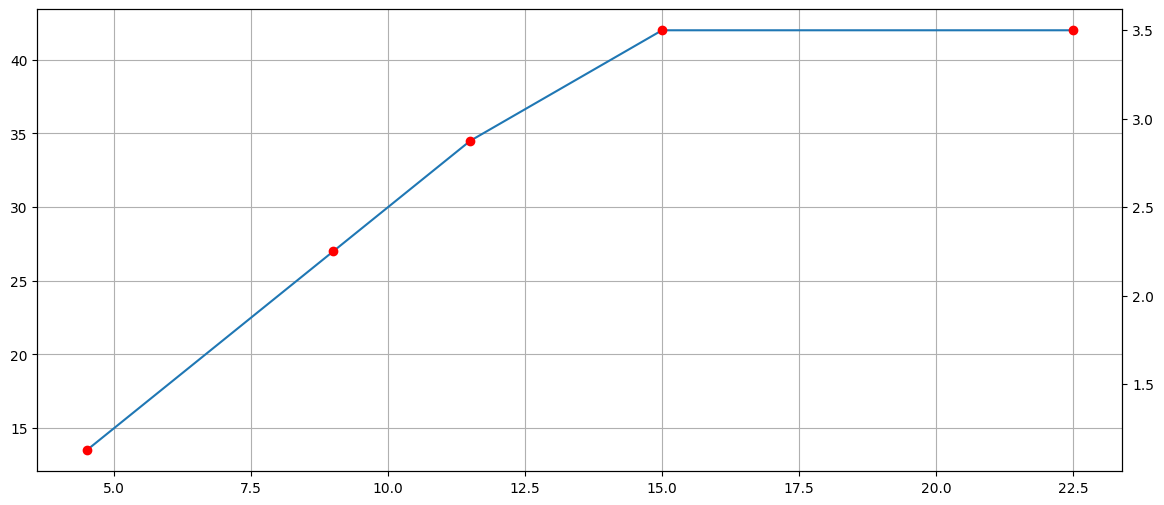

c_out r_esr: 18.34 mOhm


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
usb_c_v_tolerance = 0.1 # 10% tolerance
#v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 10)
v_in = np.array([4.5, 9, 11.5, 15, 22.5])
i_in_max = 3 # USB-C PD max current is 5, but we use 3
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 10
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

# Situations: Light (4%), Medium (25%), Full (100%)
load_ratios = np.array([0.04, 0.25, 1.0])
load_labels = ['Light', 'Medium', 'Full']

# Create a meshgrid for V_in and Load combinations
# This gives us a 2D grid of every possible operating point
VIN, LOAD = np.meshgrid(v_in, load_ratios)

# Calculate Power and Current for every point in the grid
P_OUT = np.minimum(max_load_watts * LOAD, VIN * i_in_max)
I_OUT = P_OUT / v_out

# Calculate "Effective" Duty Cycle 
# For a 4-switch Buck-Boost:
# If Vin > Vout: Buck Mode (D = Vout/Vin)
# If Vin < Vout: Boost Mode (D = 1 - Vin/Vout)
D_BUCK = np.where(VIN > v_out, v_out / VIN, 1.0)
D_BOOST = np.where(VIN < v_out, 1 - (VIN / v_out), 0.0)

input_voltage_operating_points = v_in
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

L1 = 47e-6 # from 1_.pynb
c_out_chosen_nominal = 4.7e-3 * 4
c_out_chosen_derated = 4.7e-3 * 4 * 0.7 # 4 4700 uF with 70% dc bias derating
c_out_dissipation_factor = 0.16 + 0.02 * 5
f_df = 120
r_esr = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_chosen_nominal)
print(f"c_out r_esr: {r_esr*1000:.2f} mOhm")

# feedback resistors

In [4]:
v_out = 12
r_fb1 = 20e3 # random choice, copy datasheet application. 1kOhm to 100kOhm typical
r_fb2 =  (v_out - 0.8 ) / 0.8 * r_fb1
print(f"r_fb2: {r_fb2/1000:.2f} kOhm")

r_fb2: 280.00 kOhm


# current sense resistor

In [5]:
r_sense_buck = 0.08 / max(i_out_operating_points)

i_l_max = v_out * max(i_out_operating_points) / (0.9 * min(input_voltage_operating_points))
i_l_peak = i_l_max + min(input_voltage_operating_points) * (v_out - min(input_voltage_operating_points)) / (2 * L1 * f_sw * v_out)


r_sense_buck = 0.08 / max(i_out_operating_points)
r_sense_boost = 0.12 / i_l_peak
print(f"r_sense_buck: {r_sense_buck*1000:.1f} mOhm")
print(f"r_sense_boost: {r_sense_boost*1000:.1f} mOhm")

# choose 12 mOhm or 10mOhm
r_sense = 0.010

p_r_sense_max = (0.120/r_sense) ** 2 * r_sense * (1 - min(input_voltage_operating_points) / v_out)
print(f"p_r_sense_max: {p_r_sense_max} W")

# 20mOhm 0612 (wide) 1W ERJ-B2CFR02V https://www.digikey.com/en/products/detail/panasonic-electronic-components/ERJ-B2CFR02V/3982651?_gl=1*p3aiiz*_up*MQ..*_gs*MQ..&gclid=EAIaIQobChMIgq21gvDAkwMVMzjUAR2JzS0nEAQYAiABEgKVDvD_BwE&gclsrc=aw.ds&gbraid=0AAAAADrbLliD0c621Hml0oVr6-TvI91La
# use 2 in parallel. larger size resistors has higher risk of cracking due to cte

r_sense_buck: 22.9 mOhm
r_sense_boost: 11.2 mOhm
p_r_sense_max: 0.8999999999999999 W


# slope compensation

c_slope calculated: 1.567 nF
c_slope chosen: 0.330 nF
v_comp_buck: 1.207 V
v_comp_boost: 2.145 V


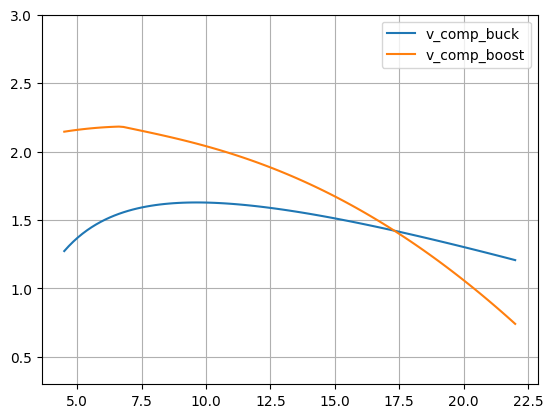

In [12]:
gm_slope = 2e-6  # datasheet
a_cs = 5  # datasheet
c_slope = gm_slope * L1 / (r_sense * a_cs)
print(f"c_slope calculated: {c_slope*1e9:.3f} nF")

c_slope = 0.33e-9 # choose smaller for noise immunity. check below if ok based on v_comp range
print(f"c_slope chosen: {c_slope*1e9:.3f} nF")

# need to check what value to use still. effect on noise immunity in buck boost transition and input output range
D_buck = v_out / input_voltage_operating_points
v_comp_buck = (
    1.6
    - a_cs * r_sense * v_out / (2 * L1 * f_sw) * (1 - D_buck)
    - (2e-6 * (input_voltage_operating_points - v_out) + 6e-6)
    / (c_slope * f_sw)
    * (1 - D_buck)
)
print(f"v_comp_buck: {v_comp_buck[-1]:.3f} V")

D_boost = 1 - input_voltage_operating_points / v_out
v_comp_boost = (
    1.6
    + a_cs
    * r_sense
    * (
        i_out_operating_points * v_out / input_voltage_operating_points
        + input_voltage_operating_points / (2 * L1 * f_sw) * D_boost
    )
    + (2e-6 * (v_out - input_voltage_operating_points) + 5e-6)
    / (c_slope * f_sw)
    * (1 - D_boost)
)

print(f"v_comp_boost: {v_comp_boost[0]:.3f} V")
plt.plot(input_voltage_operating_points, v_comp_buck, label = "v_comp_buck")
plt.plot(input_voltage_operating_points, v_comp_boost, label = "v_comp_boost")
plt.grid()
plt.ylim([0.3,3])
plt.legend()

# ok, since v_comp within 0.3V to 3V per datasheet

# UVLO

In [13]:
delta_i_hys_op = np.asarray([2.15e-6, 3.15e-6, 4.25e-6]) # datasheet
r_uv2 = 249e3 #
r_uv2 = 300e3 #
delta_v_hys_uv = delta_i_hys_op * r_uv2

print(delta_v_hys_uv)

i_en_stby = np.asarray([1e-6, 2e-6, 3e-6]) # datasheet
v_en_op = np.asarray([1.17, 1.22, 1.29]) # datasheet
r_uv1 = 100e3
v_in_uv = v_en_op * (1 + r_uv2 / r_uv1) -  r_uv2 * i_en_stby
print(v_in_uv) #rough range, just checking typical value ok for 5V usb with 500mV drop

[0.645 0.945 1.275]
[4.38 4.28 4.26]


# Soft Start
Charge output cap at least as slow as nominal output maximum current
Choose 1uF so nominal current of half of output max current

In [ ]:
print(f"{1:0.1f} uF, chosen capacitor")
# i = c dvdt
# assume max output, what dv/dtc_out_chosen_derated
dvdt = max(i_out_operating_points) / c_out_chosen_nominal
time = v_out / dvdt

print(f"time to charge output cap: {time*1e3:0.1f} ms")
vref = 0.8
iss = np.asarray([3.75, 5, 6.35])*1e-6
css = 1e-6
tss = css * vref / iss
print([f"{tss*1e3:0.1f} ms" for tss in tss])

1.0 uF, chosen capacitor
time to charge output cap: 80.6 ms
['213.3 ms', '160.0 ms', '126.0 ms']


# Frequency RT/SYNC

In [15]:
r_t = (1/f_sw - 190e-9) / 116e-12
print(f"{r_t*1e-3:0.1f} kOhm")
print(f"{82:0.1f} kOhm, chosen 5% resistor")

84.6 kOhm
82.0 kOhm, chosen 5% resistor


# Dither capacitor

In [16]:
# not implemented, populated wiht 0 Ohm resistor to ground
f_mod = 500
c_dith = 10e-6 / (f_mod * 0.24)
print(f"{c_dith*1e9:0.1f} nF")

83.3 nF


# Mosfets (calculated in 2_.ipynb)

# Frequency Compensation

In [39]:
r_out = v_out / i_out_operating_points
print(r_out)
R_OUT = v_out / I_OUT
print(R_OUT)
f_p1_boost = 1 / 2 / np.pi * (2 / (r_out * c_out_chosen_derated))
f_z1 =  1 / 2 / np.pi * (2 / (r_esr * c_out_chosen_derated))
D_max_boost = 1 - min(input_voltage_operating_points) / v_out
f_rhp_boost = 1 / 2 / np.pi * (r_out * (1 - D_max_boost) ** 2) / L1
f_p1_buck = 1 / 2 / np.pi * (1 / (r_out * c_out_chosen_derated))

print(f"f_p1_boost: {min(f_p1_boost):.1f} to {max(f_p1_boost):.1f} Hz")
print(f"f_z1: {f_z1:.1f} Hz")
print(f"f_rhp_boost: {min(f_rhp_boost):.1f} to {max(f_rhp_boost):.1f} Hz")
print(f"f_p1_buck: {min(f_p1_buck):.1f} to {max(f_p1_buck):.1f} Hz")

f_bw = 11 # based on cout calculations. less than 1/10 of max commutation speed of about 160 Hz from the load waveform as sanity check. much lower than rhp so safe
f_zc = 1 # says to place 1.5 x boost pole, but later calculations say it should be much less than f_bw. maybe our f_bw being low is weird. also. f_z1 is quite low, not sure what that means
# actually we will place at 1hz since light load, output pole may be very low, say 0.3hz..
f_p1_boost = 1 / 2 / np.pi * (2 / (R_OUT * c_out_chosen_derated))
f_z1 =  1 / 2 / np.pi * (2 / (r_esr * c_out_chosen_derated))
D_max_boost = 1 - min(input_voltage_operating_points) / v_out
f_rhp_boost = 1 / 2 / np.pi * (R_OUT * (1 - D_max_boost) ** 2) / L1
f_p1_buck = 1 / 2 / np.pi * (1 / (R_OUT * c_out_chosen_derated))

print(f"f_p1_boost: {np.min(f_p1_boost):.1f} to {np.max(f_p1_boost):.1f} Hz")
print(f"f_z1: {f_z1:.1f} Hz")
print(f"f_rhp_boost: {np.min(f_rhp_boost):.1f} to {np.max(f_rhp_boost):.1f} Hz")
print(f"f_p1_buck: {np.min(f_p1_buck):.1f} to {np.max(f_p1_buck):.1f} Hz")
f_bw2 = 680
f_zc2 = 1

[10.66666667  5.33333333  4.17391304  3.42857143  3.42857143]
[[85.71428571 85.71428571 85.71428571 85.71428571 85.71428571]
 [13.71428571 13.71428571 13.71428571 13.71428571 13.71428571]
 [10.66666667  5.33333333  4.17391304  3.42857143  3.42857143]]
f_p1_boost: 2.3 to 7.1 Hz
f_z1: 1318.7 Hz
f_rhp_boost: 1632.7 to 5079.4 Hz
f_p1_buck: 1.1 to 3.5 Hz
f_p1_boost: 0.3 to 7.1 Hz
f_z1: 1318.7 Hz
f_rhp_boost: 1632.7 to 40816.7 Hz
f_p1_buck: 0.1 to 3.5 Hz


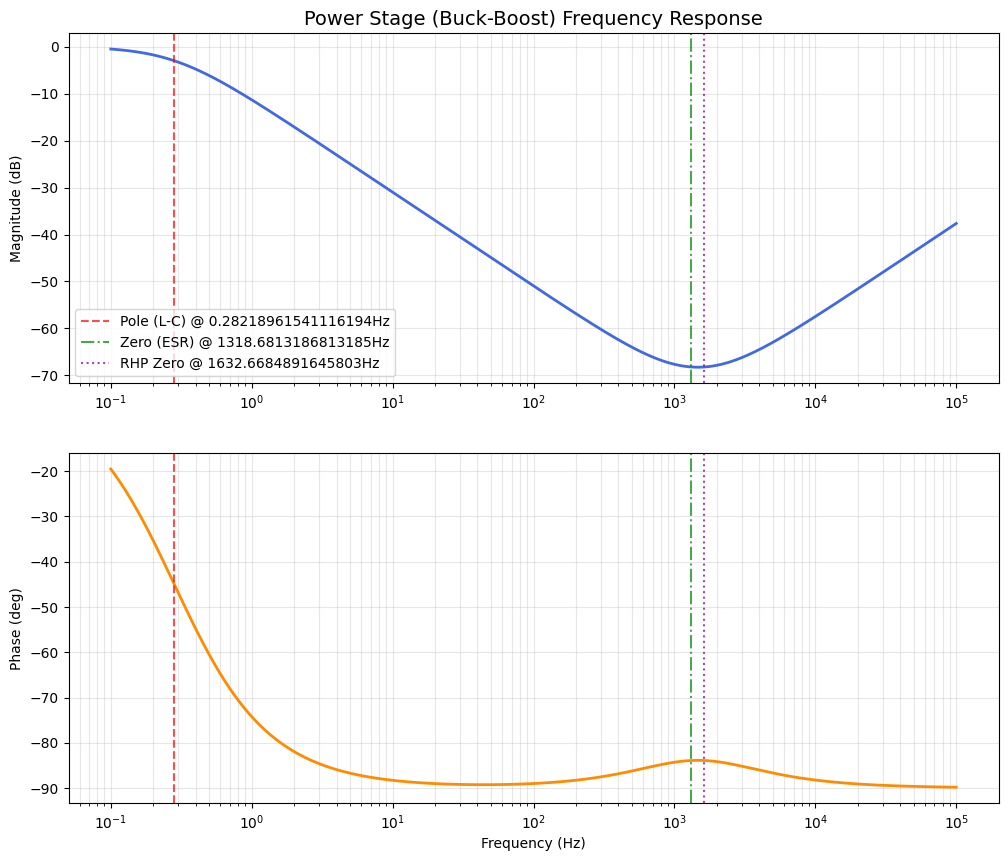

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. System Constants ---
# vc to vo
r_cs = r_sense #from previous section, 0.01ohm
a_cs = 5 #lm5176 atasheet
gain_slope_factor = 0.5 #estimating, if set slope comp to equal buck downslope? Kd in snva555. 1/2 in slva452
gain_dc = 1 / (r_cs * a_cs) * gain_slope_factor / 2 * R_OUT * (1-D_BOOST)
gm_ea = 0.00131
gain_dc = 0 # dB need to calculate still?

# Convert to rad/s for transfer function
wp1 = 2 * np.pi * np.min(f_p1_boost)
wz1 = 2 * np.pi * f_z1
wrhp = 2 * np.pi * np.min(f_rhp_boost)

# Plant TF: G(s) = Gain * (1 + s/wz1) * (1 - s/wrhp) / (1 + s/wp1)
num = 10**(gain_dc/20) * np.polymul([1/wz1, 1], [-1/wrhp, 1])
den = [1/wp1, 1]
system = signal.TransferFunction(num, den)

# --- 2. Calculate Bode Data ---
# Custom frequency range to ensure we see the low-end pole
w_hz = np.logspace(-1, 5, 1000)
w, mag, phase = signal.bode(system, w=2*np.pi*w_hz)

# --- 3. Plotting ---
plt.figure(figsize=(12, 10))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(w_hz, mag, color='royalblue', linewidth=2)
plt.title('Power Stage (Buck-Boost) Frequency Response', fontsize=14)
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both", alpha=0.3)

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(w_hz, phase, color='darkorange', linewidth=2)
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", alpha=0.3)

# --- 4. Annotations ---
features = {
    'Pole (L-C)': (wp1/2/np.pi, 'red', 'dashed'),
    'Zero (ESR)': (wz1/2/np.pi, 'green', 'dashdot'),
    'RHP Zero': (wrhp/2/np.pi, 'purple', 'dotted')
}

for label, (freq, color, style) in features.items():
    # Add vertical lines to both plots
    for ax in [1, 2]:
        plt.subplot(2, 1, ax)
        plt.axvline(freq, color=color, linestyle=style, alpha=0.7, label=f'{label} @ {freq}Hz')
    
    # Add text label to Magnitude plot
    plt.subplot(2, 1, 1)
plt.legend()

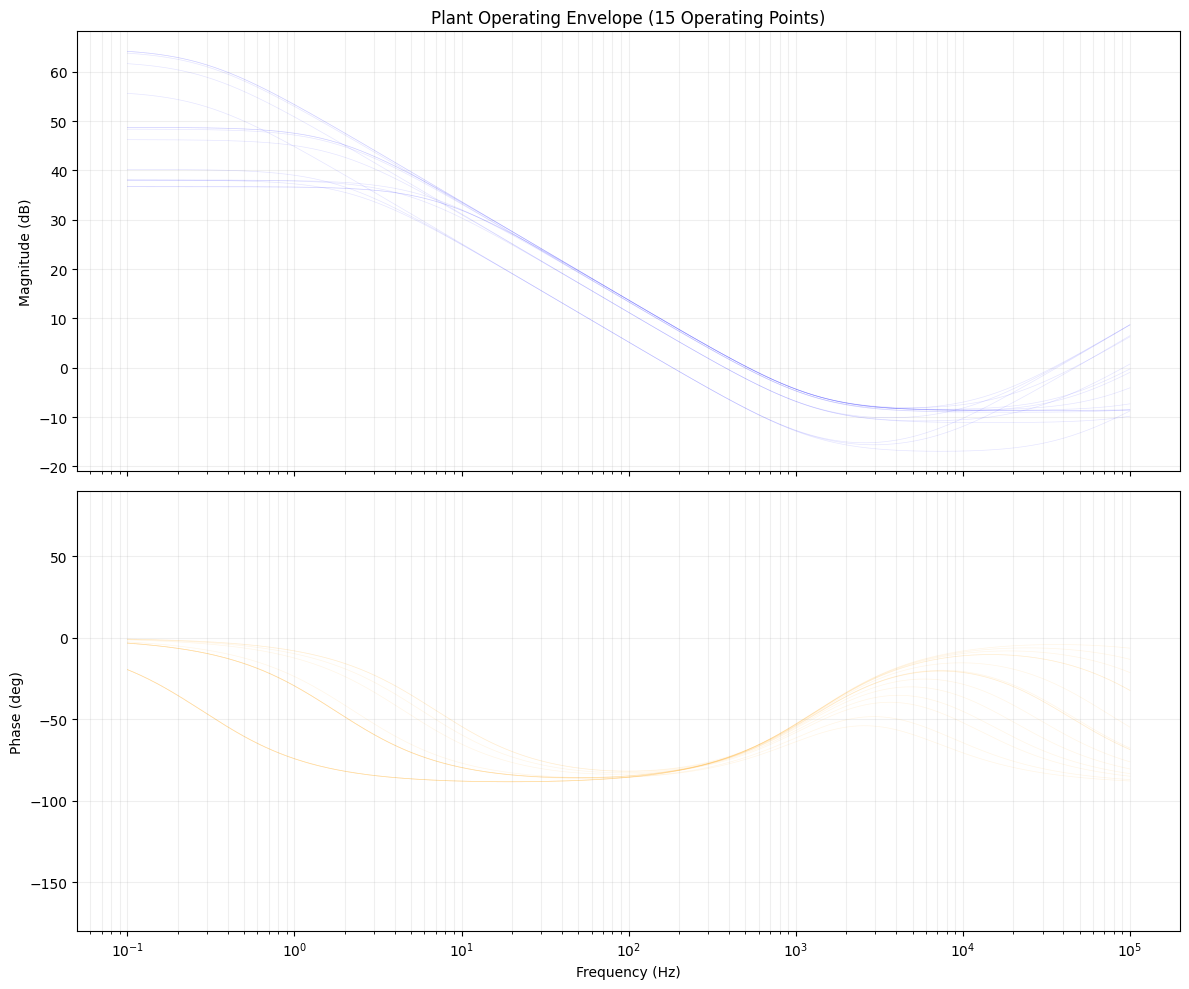

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. Flatten the Mesh for Iteration ---
v_in_flat = VIN.flatten()
r_out_flat = R_OUT.flatten()
d_boost_flat = D_BOOST.flatten()

# Setup Frequency Range
w_hz = np.logspace(-1, 5, 1000)
w_rad = 2 * np.pi * w_hz

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- 2. Loop Through Every Operating Point ---
for i in range(len(v_in_flat)):
    # Local Parameters for this specific point
    R_val = r_out_flat[i]
    D_val = d_boost_flat[i]
    Vin_val = v_in_flat[i]
    
    # Recalculate local Pole/Zero
    # Boost Pole: 2 / (2*pi*R*C)
    
    wp = 2 * np.pi * (1 / (2 * np.pi * (R_val/2) * c_out_chosen_derated))
    # RHP Zero: (R * (Vin/Vout)^2) / (2*pi*L)
    wrhp = 2 * np.pi * ((R_val * (Vin_val/v_out)**2) / (2 * np.pi * L1))
    wz_esr = 2 * np.pi * f_z1 # Constant
    
    # Local DC Gain
    gain_linear = (R_val * (1 - D_val)) / (r_cs * a_cs)
    
    # Construct TF
    num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
    den = [1/wp, 1]
    sys = signal.TransferFunction(num, den)
    
    # Calculate Bode
    _, mag, phase = signal.bode(sys, w=w_rad)
    
    # Plot with high transparency (alpha)
    ax_mag.semilogx(w_hz, mag, color='blue', alpha=0.1, linewidth=0.5)
    ax_phase.semilogx(w_hz, phase, color='orange', alpha=0.1, linewidth=0.5)

# --- 3. Formatting ---
ax_mag.set_title(f'Plant Operating Envelope ({len(v_in_flat)} Operating Points)')
ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.grid(True, which="both", alpha=0.2)

ax_phase.set_ylabel('Phase (deg)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.set_ylim(-180, 90) # Standard range for stability check
ax_phase.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

R_fb2: 280.0 kOhm
Rc: 1.4 kOhm
Cc: 114.613 uF
Chf: 114.61 nF
Cc: 220.000 nF, chosen capacitor
Chf: 150.00 nF, chosen capacitor


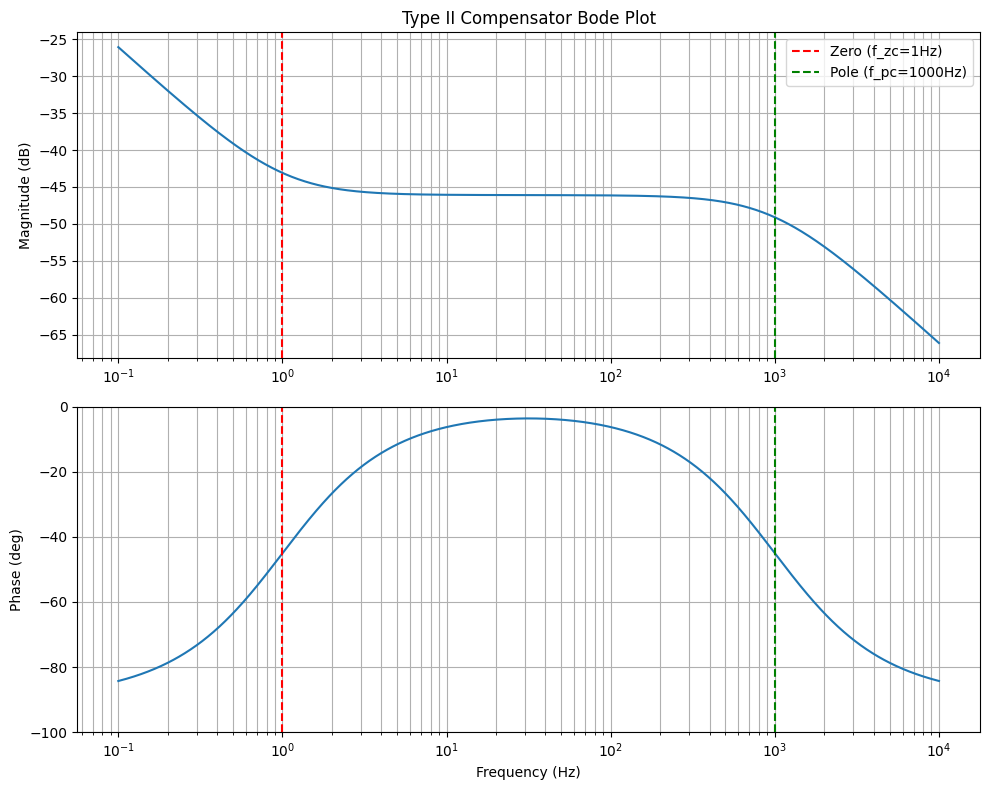

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Corrected variable names
v_out = 12
r_fb1 = 20e3
r_fb2 = (v_out - 0.8) / 0.8 * r_fb1 # 280k
v_ref = 0.8

# Frequencies
f_pc = 1000     # High frequency pole, 7 to 10x bw
#f_bw = f_bw2
#f_zc = f_zc2

# Design values for components
Rc = 2 * np.pi / gm_ea * (r_fb1 + r_fb2) / r_fb1 * a_cs * r_cs * c_out_chosen_derated / (1-D_max_boost) * f_bw
Cc = 1 / (2 * np.pi * Rc * f_zc)
Chf = 1 / (2 * np.pi * Rc * f_pc)

# Transfer Function for Type II Op-Amp Compensator:
# H(s) = (1 + s*Rc*Cc) / (s*r_fb2*(Cc + Chf) * (1 + s*Rc*Cc*Chf/(Cc+Chf)))

num = [Rc * Cc, 1]
# Denominator coefficients: s^2 * [r_fb2 * (Cc+Chf) * Rc * Cc * Chf / (Cc+Chf)] + s * [r_fb2 * (Cc+Chf)] + 0
den = [r_fb2 * Rc * Cc * Chf, r_fb2 * (Cc + Chf), 0]

sys_comp = signal.TransferFunction(num, den)

# Frequencies for plot: 0.1 Hz to 10 kHz
w_hz = np.logspace(-1, 4, 1000)
w = 2 * np.pi * w_hz
w, mag, phase = signal.bode(sys_comp, w)

plt.figure(figsize=(10, 8))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(w_hz, mag)
plt.title('Type II Compensator Bode Plot')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which="both")
plt.axvline(f_zc, color='r', linestyle='--', label=f'Zero (f_zc={f_zc}Hz)')
plt.axvline(f_pc, color='g', linestyle='--', label=f'Pole (f_pc={f_pc}Hz)')
plt.legend()

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(w_hz, phase)
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.ylim(-100, 0)
plt.grid(True, which="both")
plt.axvline(f_zc, color='r', linestyle='--')
plt.axvline(f_pc, color='g', linestyle='--')

plt.tight_layout()
plt.savefig('compensator_bode_plot.png')

print(f"R_fb2: {r_fb2/1000:.1f} kOhm")
print(f"Rc: {Rc/1000:.1f} kOhm")
print(f"Cc: {Cc*1e6:.3f} uF")
print(f"Chf: {Chf*1e9:.2f} nF")
print(f"Cc: {220:.3f} nF, chosen capacitor")
print(f"Chf: {150:.2f} nF, chosen capacitor")

=== BOOST MODE (Vin < 12V) ===


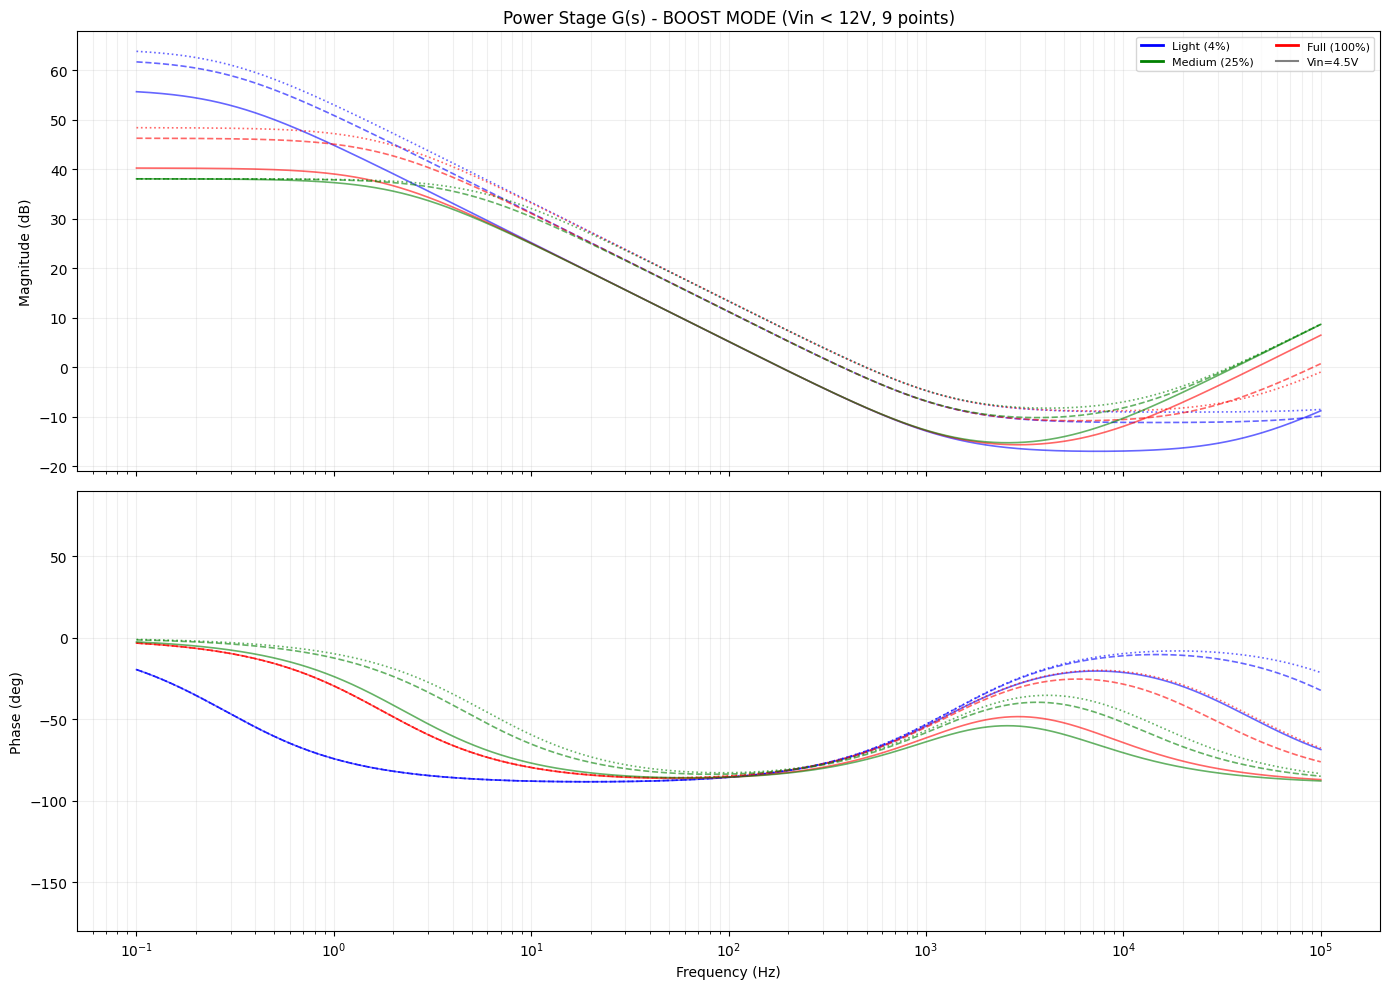

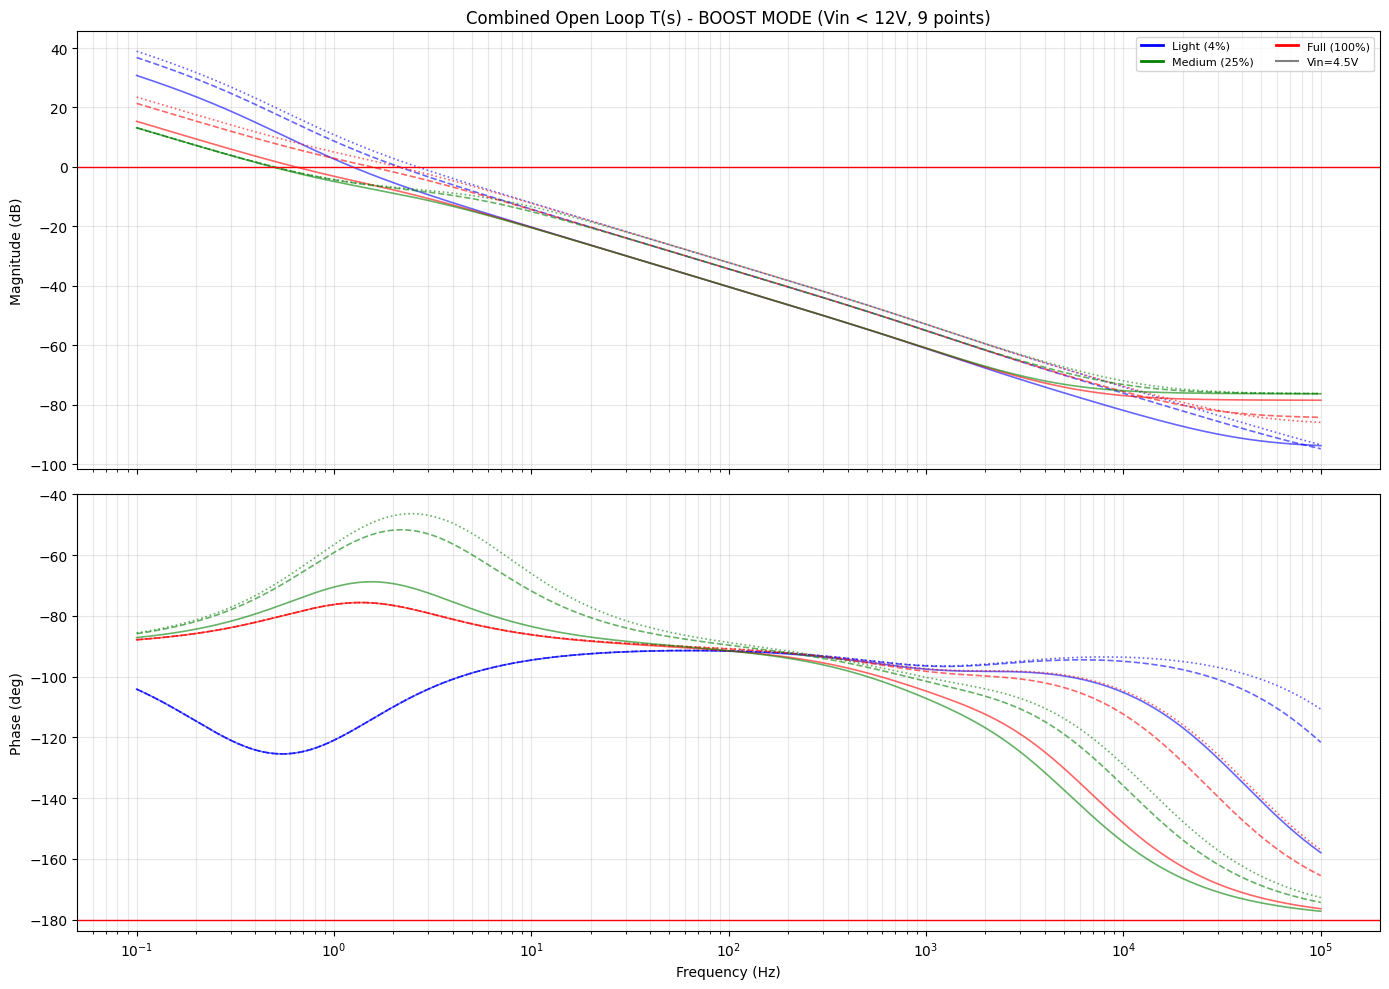


=== BUCK MODE (Vin > 12V) ===


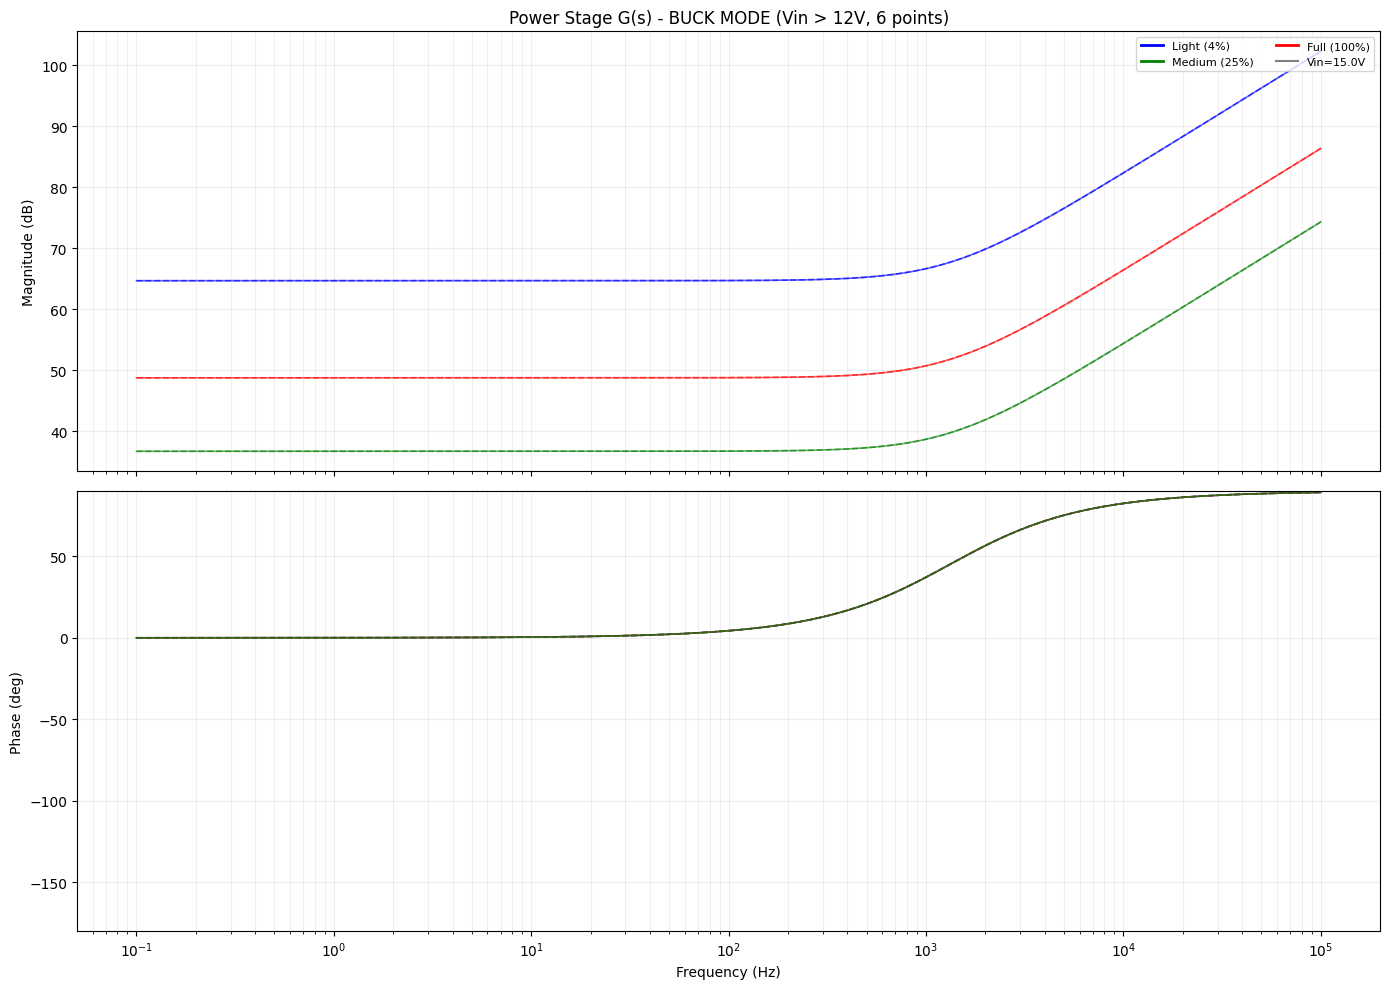

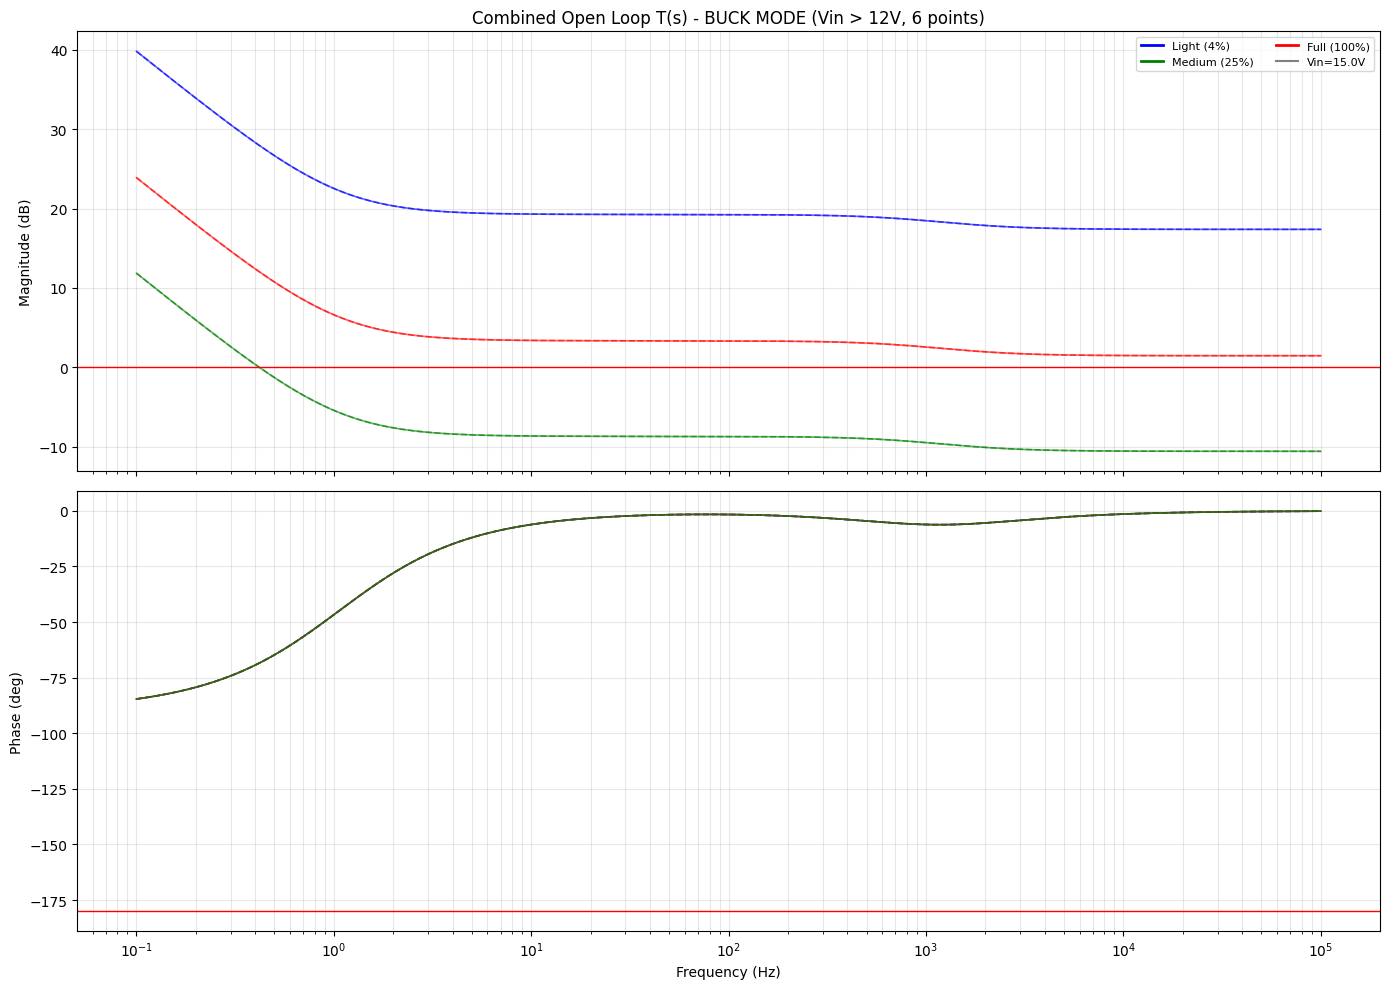


Boost mode: 9 points (Vin < 12V)
Buck mode: 6 points (Vin > 12V)
R_fb2: 280.0 kOhm
Rc: 1.4 kOhm
Cc: 114.613 uF
Chf: 114.61 nF
Rc: 1.5 kOhm, implemented 5% resistor
Cc: 100.000 uF, implemented capacitor
Chf: 100.00 nF, implemented capacitor
Cc: 220.000 nF, chosen capacitor
Chf: 150.00 nF, chosen capacitor


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from matplotlib.lines import Line2D

# --- 1. Flatten the Mesh for Iteration ---
v_in_flat = VIN.flatten()
r_out_flat = R_OUT.flatten()
d_boost_flat = D_BOOST.flatten()
d_buck_flat = D_BUCK.flatten()
load_flat = LOAD.flatten()  # Track load ratio for color mapping

# Calculate output power for each operating point
p_out_flat = v_out * I_OUT.flatten()

# Setup colormap based on load (color) and linestyle based on input voltage
load_labels = ['Light (4%)', 'Medium (25%)', 'Full (100%)']
load_colors = ['blue', 'green', 'red']
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (1, 1)), (0, (5, 2, 5, 2)), (0, (3, 3, 1, 3)), (0, (2, 1, 2, 1)), (0, (4, 1, 4, 1))]

# Get unique input voltages
unique_vin = np.unique(v_in_flat)

# Setup Frequency Range
w_hz = np.logspace(-1, 5, 1500)
w_rad = 2 * np.pi * w_hz

# ==============================================================================
# BOOST MODE PLOTS (Vin < Vout)
# ==============================================================================
print("=== BOOST MODE (Vin < 12V) ===")

# Filter for boost mode only
boost_mask = v_in_flat < v_out
v_in_boost = v_in_flat[boost_mask]
r_out_boost = r_out_flat[boost_mask]
d_boost_boost = d_boost_flat[boost_mask]
load_boost = load_flat[boost_mask]
p_out_boost = p_out_flat[boost_mask]

# Get unique boost input voltages
unique_vin_boost = np.unique(v_in_boost)

fig_boost, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i in range(len(v_in_boost)):
    R_val = r_out_boost[i]
    D_val = d_boost_boost[i]
    Vin_val = v_in_boost[i]
    
    # Boost mode poles/zeros
    wp = 2 * np.pi * (1 / (2 * np.pi * (R_val/2) * c_out_chosen_derated))
    wrhp = 2 * np.pi * ((R_val * (Vin_val/v_out)**2) / (2 * np.pi * L1))
    wz_esr = 2 * np.pi * f_z1
    
    gain_linear = (R_val * (1 - D_val)) / (r_cs * a_cs)
    
    num = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
    den = [1/wp, 1]
    sys_ps = signal.TransferFunction(num, den)
    
    _, mag_ps, phase_ps = signal.bode(sys_ps, w=w_rad)
    
    vin_idx = np.where(unique_vin_boost == Vin_val)[0][0]
    linestyle = linestyles[vin_idx % len(linestyles)]
    load_idx = np.where(np.isclose(LOAD.flatten(), load_boost[i]))[0][0] % 3
    color = load_colors[load_idx]
    
    ax_mag.semilogx(w_hz, mag_ps, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)
    ax_phase.semilogx(w_hz, phase_ps, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)

# Legend
legend_elements = []
for j, load_label in enumerate(load_labels):
    legend_elements.append(Line2D([0], [0], color=load_colors[j], linewidth=2, label=load_label))
for k, vin in enumerate(unique_vin_boost[::3]):
    vin_idx = np.where(unique_vin_boost == vin)[0][0]
    legend_elements.append(Line2D([0], [0], color='gray', linestyle=linestyles[vin_idx % len(linestyles)], 
                                   linewidth=1.5, label=f'Vin={vin:.1f}V'))

ax_mag.legend(handles=legend_elements, loc='upper right', fontsize=8, ncol=2)
ax_mag.set_title(f'Power Stage G(s) - BOOST MODE (Vin < {v_out}V, {len(v_in_boost)} points)')
ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.grid(True, which="both", alpha=0.2)

ax_phase.set_ylabel('Phase (deg)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.set_ylim(-180, 90)
ax_phase.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.savefig('power_stage_bode_boost.png')
plt.show()

# --- Compensator H(s) ---
Rfb2 = r_fb2
Rc_implemented = 1.5e3
Cc_implemented = 100e-6
Chf_implemented = 100e-9

num_h = [Rc_implemented * Cc_implemented, 1]
den_h = [Rfb2 * Rc_implemented * Cc_implemented * Chf_implemented, Rfb2 * (Cc_implemented + Chf_implemented), 0]
sys_comp = signal.TransferFunction(num_h, den_h)

# --- Combined Open Loop T(s) - BOOST ---
fig3_boost, (ax_mag3, ax_phase3) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i in range(len(v_in_boost)):
    R_val = r_out_boost[i]
    D_val = d_boost_boost[i]
    Vin_val = v_in_boost[i]
    
    wp = 2 * np.pi * (1 / (2 * np.pi * (R_val/2) * c_out_chosen_derated))
    wrhp = 2 * np.pi * ((R_val * (Vin_val/v_out)**2) / (2 * np.pi * L1))
    wz_esr = 2 * np.pi * f_z1
    
    gain_linear = (R_val * (1 - D_val)) / (r_cs * a_cs)
    
    num_ps = gain_linear * np.polymul([1/wz_esr, 1], [-1/wrhp, 1])
    den_ps = [1/wp, 1]
    sys_ps = signal.TransferFunction(num_ps, den_ps)
    
    num_total = np.polymul(sys_ps.num, sys_comp.num)
    den_total = np.polymul(sys_ps.den, sys_comp.den)
    sys_total = signal.TransferFunction(num_total, den_total)
    
    _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
    
    vin_idx = np.where(unique_vin_boost == Vin_val)[0][0]
    linestyle = linestyles[vin_idx % len(linestyles)]
    load_idx = np.where(np.isclose(LOAD.flatten(), load_boost[i]))[0][0] % 3
    color = load_colors[load_idx]
    
    ax_mag3.semilogx(w_hz, mag_total, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)
    ax_phase3.semilogx(w_hz, phase_total, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)

legend_elements3 = []
for j, load_label in enumerate(load_labels):
    legend_elements3.append(Line2D([0], [0], color=load_colors[j], linewidth=2, label=load_label))
for k, vin in enumerate(unique_vin_boost[::3]):
    vin_idx = np.where(unique_vin_boost == vin)[0][0]
    legend_elements3.append(Line2D([0], [0], color='gray', linestyle=linestyles[vin_idx % len(linestyles)], 
                                   linewidth=1.5, label=f'Vin={vin:.1f}V'))

ax_mag3.legend(handles=legend_elements3, loc='upper right', fontsize=8, ncol=2)
ax_mag3.axhline(0, color='red', linewidth=1, linestyle='-', label='0 dB')
ax_mag3.set_title(f'Combined Open Loop T(s) - BOOST MODE (Vin < {v_out}V, {len(v_in_boost)} points)')
ax_mag3.set_ylabel('Magnitude (dB)')
ax_mag3.grid(True, which="both", alpha=0.3)

ax_phase3.axhline(-180, color='red', linewidth=1, linestyle='-', label='-180°')
ax_phase3.set_ylabel('Phase (deg)')
ax_phase3.set_xlabel('Frequency (Hz)')
ax_phase3.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig('combined_bode_boost.png')
plt.show()

# ==============================================================================
# BUCK MODE PLOTS (Vin > Vout)
# ==============================================================================
print("\n=== BUCK MODE (Vin > 12V) ===")

# Filter for buck mode only
buck_mask = v_in_flat > v_out
v_in_buck = v_in_flat[buck_mask]
r_out_buck = r_out_flat[buck_mask]
d_buck_buck = d_buck_flat[buck_mask]
load_buck = load_flat[buck_mask]
p_out_buck = p_out_flat[buck_mask]

# Get unique buck input voltages
unique_vin_buck = np.unique(v_in_buck)

fig_buck, (ax_mag_b, ax_phase_b) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i in range(len(v_in_buck)):
    R_val = r_out_buck[i]
    D_val = d_buck_buck[i]
    Vin_val = v_in_buck[i]
    
    # Buck mode: pole at 1/(2*pi*R*C), no RHP zero, ESR zero still exists
    wp_buck = 2 * np.pi * (1 / (2 * np.pi * R_val * c_out_chosen_derated))
    wz_esr = 2 * np.pi * f_z1
    
    # Buck DC gain: R_out / (r_sense * a_cs)
    gain_linear = R_val / (r_cs * a_cs)
    
    # Buck TF: Gain * (1 + s/wz_esr) / (1 + s/wp_buck)
    num = gain_linear * np.polymul([1/wz_esr, 1], [1/wp_buck, 1])
    den = [1/wp_buck, 1]
    sys_ps = signal.TransferFunction(num, den)
    
    _, mag_ps, phase_ps = signal.bode(sys_ps, w=w_rad)
    
    vin_idx = np.where(unique_vin_buck == Vin_val)[0][0]
    linestyle = linestyles[vin_idx % len(linestyles)]
    load_idx = np.where(np.isclose(LOAD.flatten(), load_buck[i]))[0][0] % 3
    color = load_colors[load_idx]
    
    ax_mag_b.semilogx(w_hz, mag_ps, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)
    ax_phase_b.semilogx(w_hz, phase_ps, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)

# Legend
legend_elements_b = []
for j, load_label in enumerate(load_labels):
    legend_elements_b.append(Line2D([0], [0], color=load_colors[j], linewidth=2, label=load_label))
for k, vin in enumerate(unique_vin_buck[::3]):
    vin_idx = np.where(unique_vin_buck == vin)[0][0]
    legend_elements_b.append(Line2D([0], [0], color='gray', linestyle=linestyles[vin_idx % len(linestyles)], 
                                   linewidth=1.5, label=f'Vin={vin:.1f}V'))

ax_mag_b.legend(handles=legend_elements_b, loc='upper right', fontsize=8, ncol=2)
ax_mag_b.set_title(f'Power Stage G(s) - BUCK MODE (Vin > {v_out}V, {len(v_in_buck)} points)')
ax_mag_b.set_ylabel('Magnitude (dB)')
ax_mag_b.grid(True, which="both", alpha=0.2)

ax_phase_b.set_ylabel('Phase (deg)')
ax_phase_b.set_xlabel('Frequency (Hz)')
ax_phase_b.set_ylim(-180, 90)
ax_phase_b.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.savefig('power_stage_bode_buck.png')
plt.show()

# --- Combined Open Loop T(s) - BUCK ---
fig3_buck, (ax_mag3_b, ax_phase3_b) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i in range(len(v_in_buck)):
    R_val = r_out_buck[i]
    D_val = d_buck_buck[i]
    Vin_val = v_in_buck[i]
    
    wp_buck = 2 * np.pi * (1 / (2 * np.pi * R_val * c_out_chosen_derated))
    wz_esr = 2 * np.pi * f_z1
    
    # Buck DC gain: R_out / (r_sense * a_cs)
    gain_linear = R_val / (r_cs * a_cs)
    
    num_ps = gain_linear * np.polymul([1/wz_esr, 1], [1/wp_buck, 1])
    den_ps = [1/wp_buck, 1]
    sys_ps = signal.TransferFunction(num_ps, den_ps)
    
    num_total = np.polymul(sys_ps.num, sys_comp.num)
    den_total = np.polymul(sys_ps.den, sys_comp.den)
    sys_total = signal.TransferFunction(num_total, den_total)
    
    _, mag_total, phase_total = signal.bode(sys_total, w=w_rad)
    
    vin_idx = np.where(unique_vin_buck == Vin_val)[0][0]
    linestyle = linestyles[vin_idx % len(linestyles)]
    load_idx = np.where(np.isclose(LOAD.flatten(), load_buck[i]))[0][0] % 3
    color = load_colors[load_idx]
    
    ax_mag3_b.semilogx(w_hz, mag_total, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)
    ax_phase3_b.semilogx(w_hz, phase_total, color=color, linestyle=linestyle, alpha=0.6, linewidth=1.2)

legend_elements3_b = []
for j, load_label in enumerate(load_labels):
    legend_elements3_b.append(Line2D([0], [0], color=load_colors[j], linewidth=2, label=load_label))
for k, vin in enumerate(unique_vin_buck[::3]):
    vin_idx = np.where(unique_vin_buck == vin)[0][0]
    legend_elements3_b.append(Line2D([0], [0], color='gray', linestyle=linestyles[vin_idx % len(linestyles)], 
                                   linewidth=1.5, label=f'Vin={vin:.1f}V'))

ax_mag3_b.legend(handles=legend_elements3_b, loc='upper right', fontsize=8, ncol=2)
ax_mag3_b.axhline(0, color='red', linewidth=1, linestyle='-', label='0 dB')
ax_mag3_b.set_title(f'Combined Open Loop T(s) - BUCK MODE (Vin > {v_out}V, {len(v_in_buck)} points)')
ax_mag3_b.set_ylabel('Magnitude (dB)')
ax_mag3_b.grid(True, which="both", alpha=0.3)

ax_phase3_b.axhline(-180, color='red', linewidth=1, linestyle='-', label='-180°')
ax_phase3_b.set_ylabel('Phase (deg)')
ax_phase3_b.set_xlabel('Frequency (Hz)')
ax_phase3_b.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig('combined_bode_buck.png')
plt.show()

print(f"\nBoost mode: {len(v_in_boost)} points (Vin < {v_out}V)")
print(f"Buck mode: {len(v_in_buck)} points (Vin > {v_out}V)")

print(f"R_fb2: {r_fb2/1000:.1f} kOhm")
print(f"Rc: {Rc/1000:.1f} kOhm")
print(f"Cc: {Cc*1e6:.3f} uF")
print(f"Chf: {Chf*1e9:.2f} nF")
print(f"Rc: {Rc_implemented/1000:.1f} kOhm, implemented 5% resistor")
print(f"Cc: {Cc_implemented*1e6:.3f} uF, implemented capacitor")
print(f"Chf: {Chf_implemented*1e9:.2f} nF, implemented capacitor")

print(f"Cc: {220:.3f} nF, chosen capacitor")
print(f"Chf: {150:.2f} nF, chosen capacitor")